In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median()) 


In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [10]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)


In [11]:
df.duplicated().sum()

0

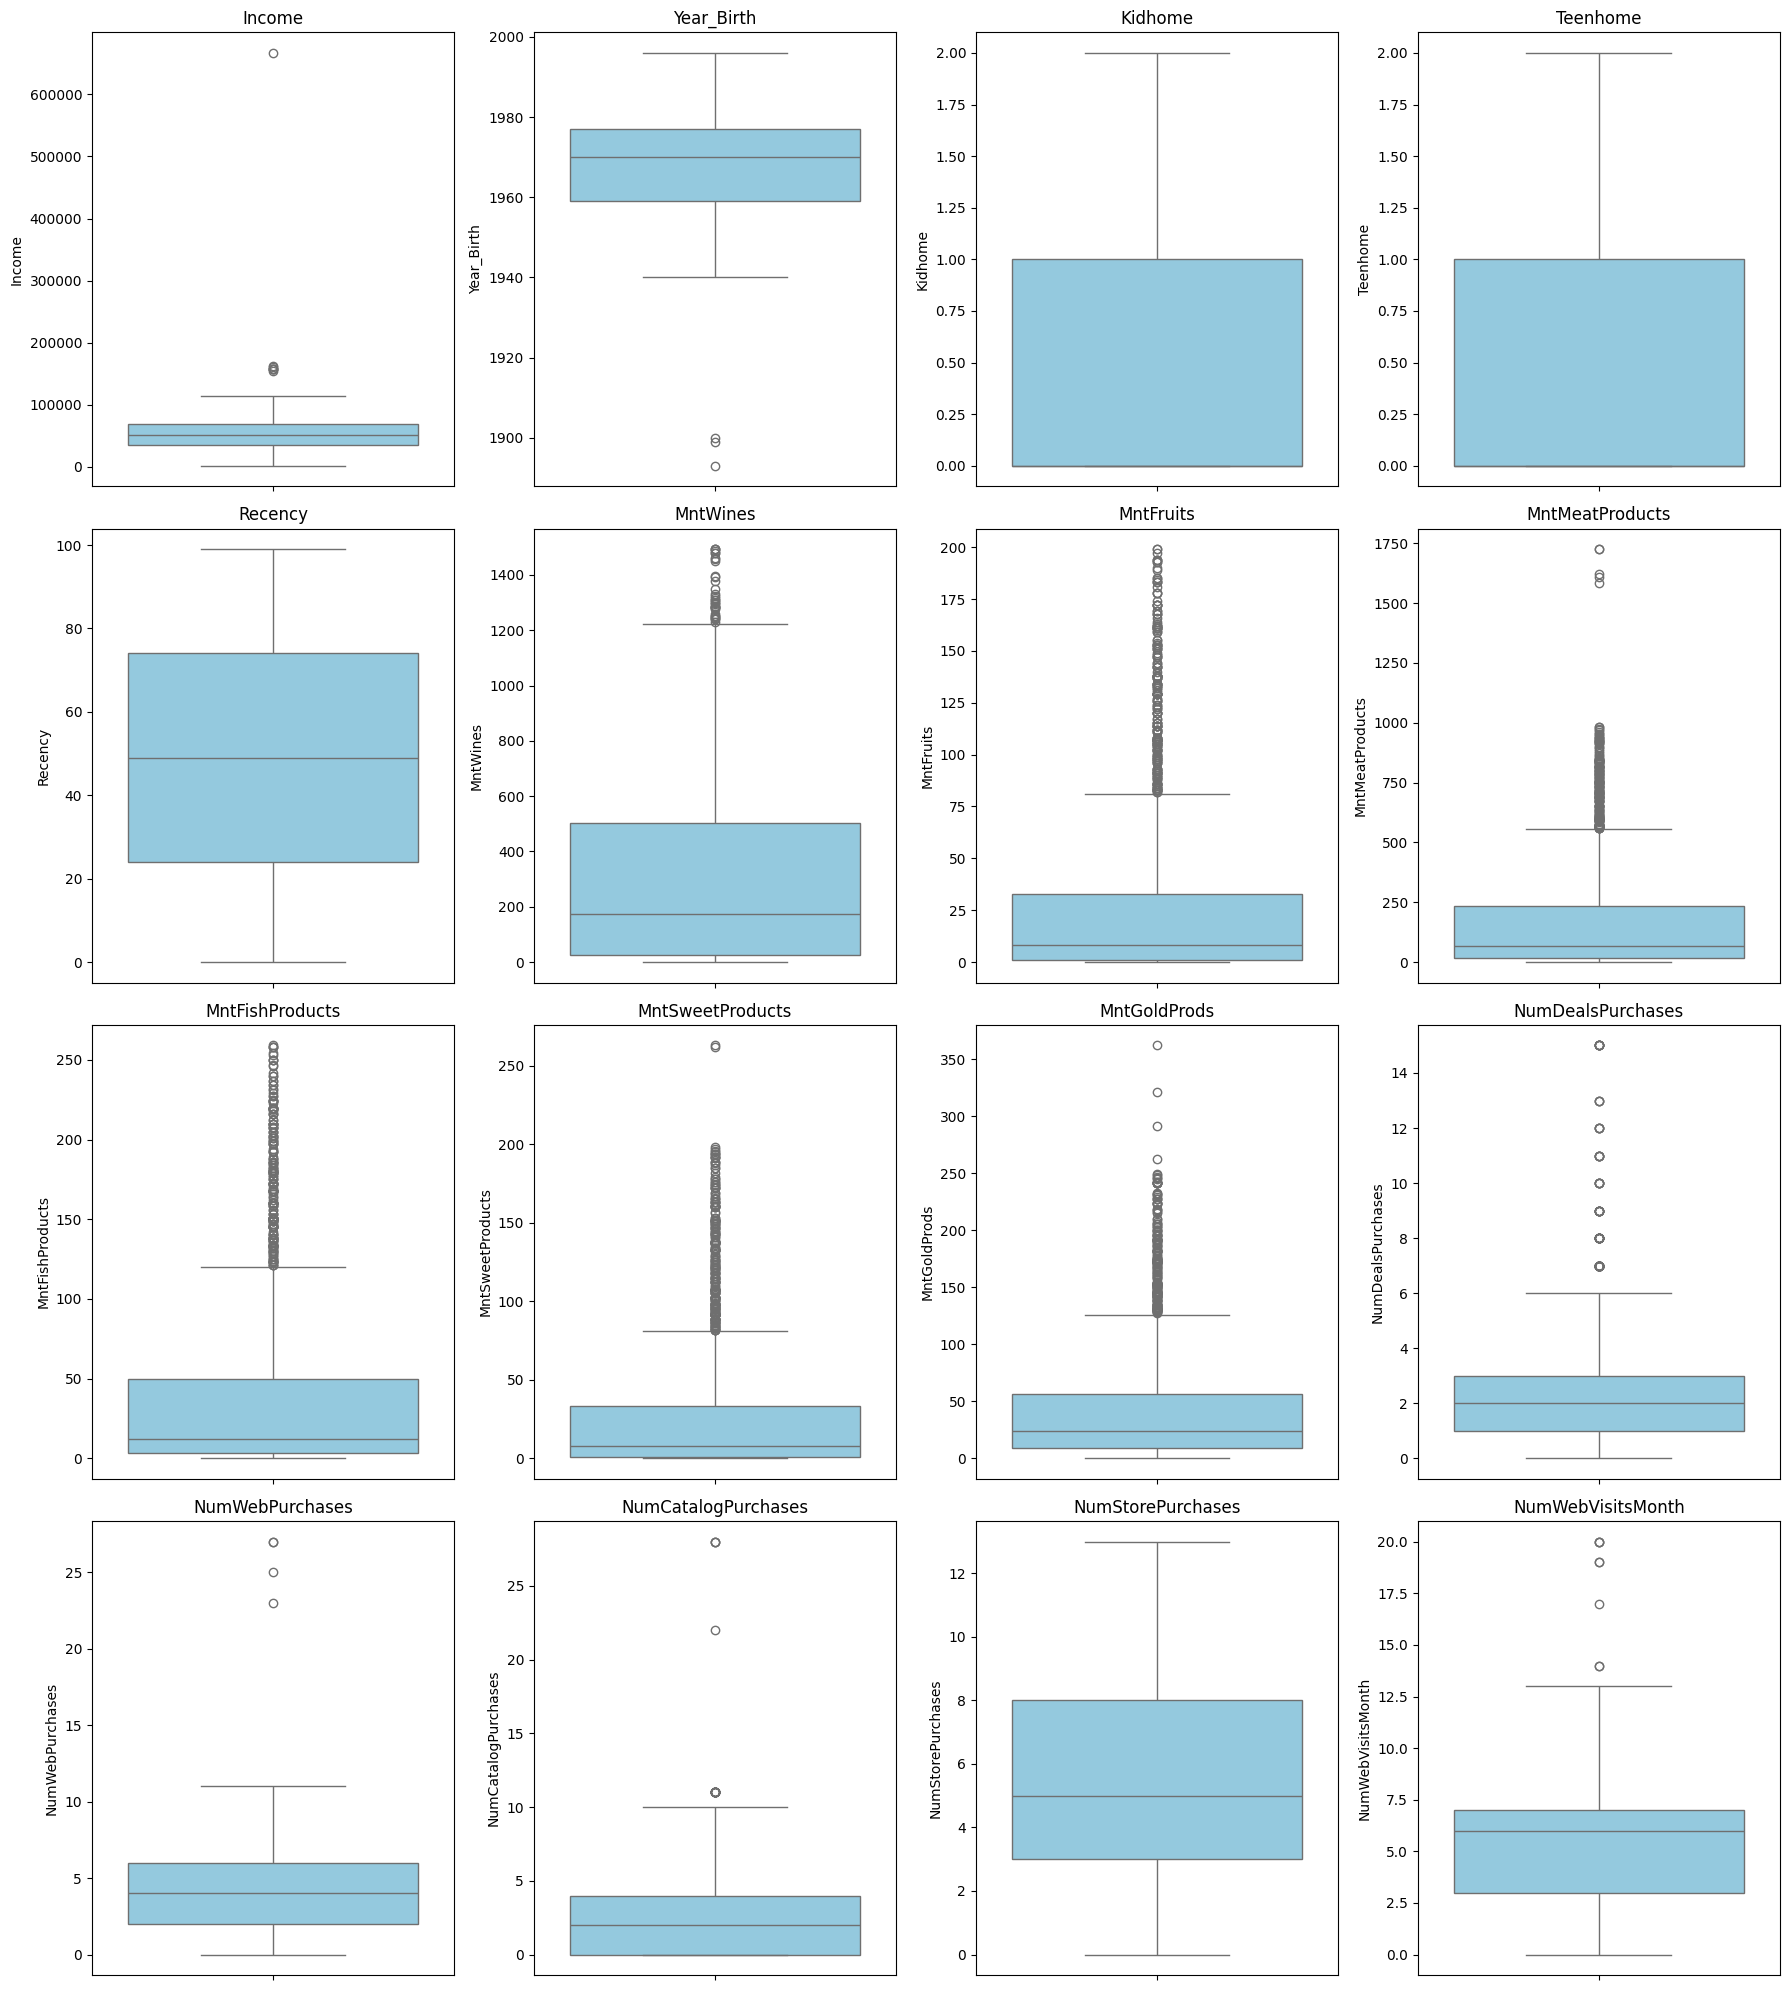

In [14]:
num_vars = [
'Income','Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 
'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 
'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 
'NumWebVisitsMonth'
]

# Set figure size and layout
plt.figure(figsize=(18, 20))

# Loop and plot
for i, col in enumerate(num_vars, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.xlabel("")  # Optional: remove x-axis label for cleaner look

plt.tight_layout()
plt.show()

<Axes: ylabel='Income'>

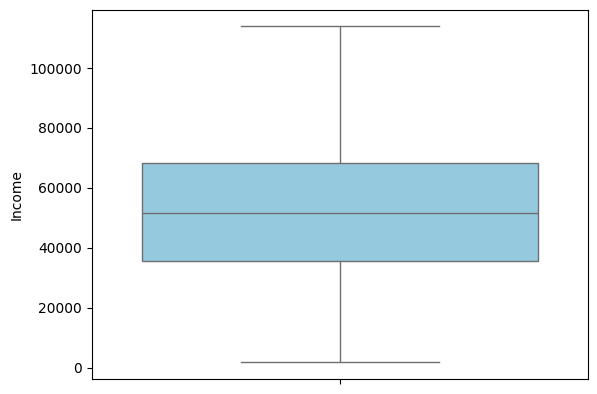

In [15]:
# Removing outliers in Income 
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]
sns.boxplot(y=df['Income'], color='skyblue')

<Axes: ylabel='Year_Birth'>

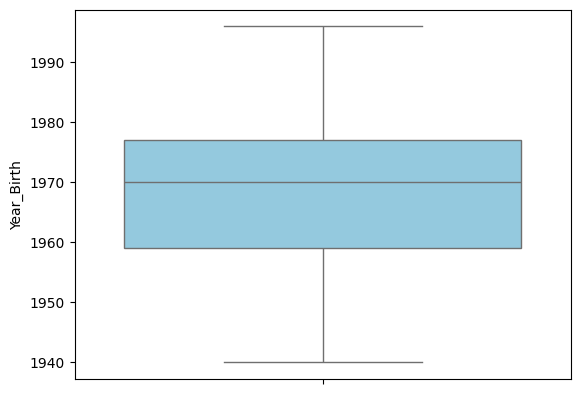

In [16]:
# Removing outliers in Year birth column
Q1 = df['Year_Birth'].quantile(0.25)
Q3 = df['Year_Birth'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['Year_Birth'] >= lower_bound) & (df['Year_Birth'] <= upper_bound)]
sns.boxplot(y=df['Year_Birth'], color='skyblue')

Feature Engineering (Add Columns)

In [23]:
import datetime as dt
current_year = dt.datetime.now().year
current_year

2025

In [24]:
# Adding Age column that identify the Age of each Customer has enrolled 
df['Age'] = current_year - df['Year_Birth']

In [25]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [26]:
def eductation_level(education):
    if education in ['Graduation', 'PhD', 'Master'] :
        return 'High'
    elif education in ['Basic'] :
        return 'Middle'
    else :
        return 'Low'

df['Education_level'] = df['Education'].apply(eductation_level)    

In [27]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [28]:
def living_status (martial_stat):
    if martial_stat in ['Alone','YOLO','Absurd','Single'] :
        return 'Living Alone'
    else:
        return 'Living with others'
df['Living_Status'] = df['Marital_Status'].apply(living_status)

In [29]:
df['Living_Status'].value_counts()

Living_Status
Living with others    1743
Living Alone           486
Name: count, dtype: int64

In [30]:
df['Marital_Status'].value_counts()

Marital_Status
Married     861
Together    575
Single      479
Divorced    230
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [31]:
to_drop = ['Z_CostContact', 'Z_Revenue', 'Year_Birth' ,'Complain' , 'Kidhome','Teenhome' ,'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2']
df = df.drop(to_drop, axis=1)

In [32]:
df.shape

(2229, 21)

In [34]:
import datetime as dt

# Reference date = latest date in dataset
ref_date = df["Dt_Customer"].max() + pd.Timedelta(days=1)

# Recency (days since last purchase)
df["Recency"] = (ref_date - df["Dt_Customer"]).dt.days

# Frequency (total purchases)
df["Frequency"] = df["NumStorePurchases"] + df["NumWebPurchases"] + df["NumCatalogPurchases"]

# Monetary (total spend)
df["Monetary"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

rfm = df[["Recency", "Frequency", "Monetary"]]
rfm.head()


,Recency,Frequency,Monetary
0,664,22,1617
1,114,4,27
2,313,20,776
3,140,6,53
4,162,14,422


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

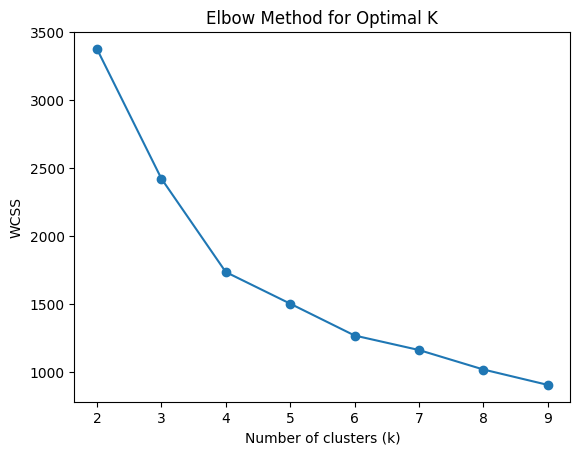

In [37]:
from sklearn.cluster import KMeans
wcss = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 10), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


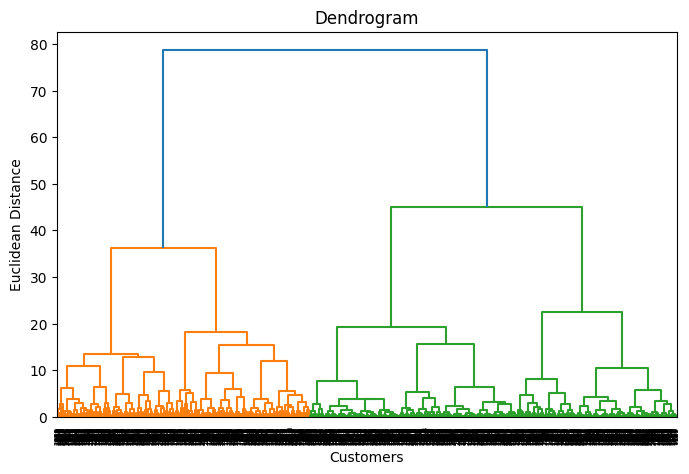

In [38]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(8, 5))
dendrogram = sch.dendrogram(sch.linkage(rfm_scaled, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()


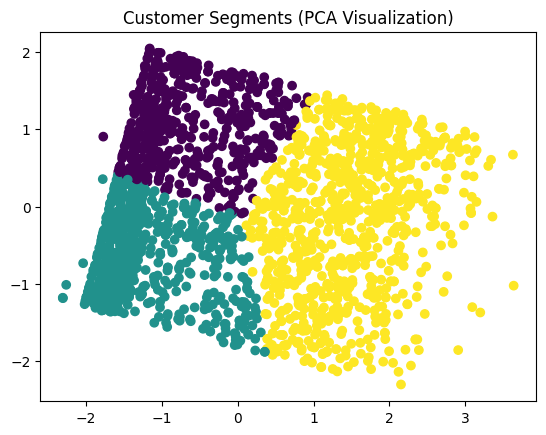

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
rfm_pca = pca.fit_transform(rfm_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)

plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=clusters, cmap="viridis")
plt.title("Customer Segments (PCA Visualization)")
plt.show()


In [51]:
df["Cluster"] = clusters
cluster_profile = df.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_profile)


            Recency  Frequency     Monetary
Cluster                                    
0        523.182114   7.936585   202.058537
1        166.824100   7.385042   174.601108
2        390.801570  19.909193  1232.536996


In [52]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.3946327996801254


<Axes: xlabel='Cluster', ylabel='Recency'>

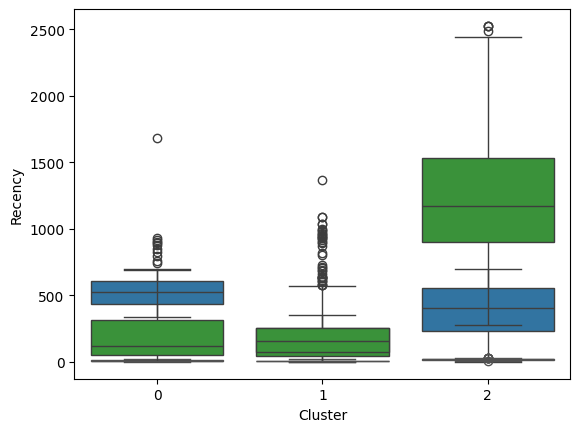

In [53]:
sns.boxplot(x="Cluster", y="Recency", data=df)
sns.boxplot(x="Cluster", y="Frequency", data=df)
sns.boxplot(x="Cluster", y="Monetary", data=df)